## recall is more important in imbalance datasets 

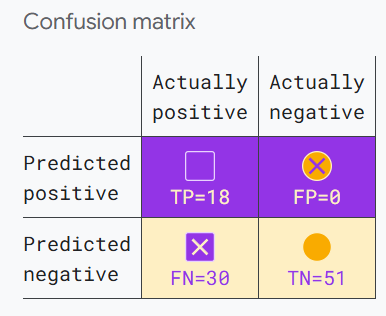

### Precision improves as false positives decrease, while recall improves when false negatives decrease.

### increasing the classification threshold tends to decrease the number of false positives and increase the number of false negatives, while decreasing the threshold has the opposite effects

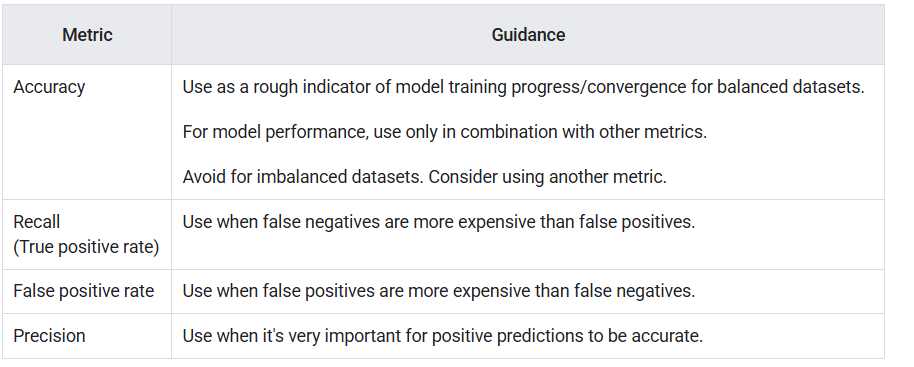

In [2]:
import keras 
import ml_edu.experiment
import ml_edu.results 
import numpy as np 
import pandas as pd 
import plotly.express as px 
#long formate like 29.283838 converge to 29.2 
pd.options.display.float_format = "{:.1f}".format 

print("ran the import statment ") 

ran the import statment 


In [3]:
#Load the dataset

rice_dataset_raw = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")

In [4]:
rice_dataset_raw.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.6,229.7,85.1,0.9,15617,0.6,Cammeo
1,14656,494.3,206.0,91.7,0.9,15072,0.6,Cammeo
2,14634,501.1,214.1,87.8,0.9,14954,0.7,Cammeo
3,13176,458.3,193.3,87.4,0.9,13368,0.6,Cammeo
4,14688,507.2,211.7,89.3,0.9,15262,0.6,Cammeo


In [5]:
rice_dataset_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,3810.0,12667.7,1732.4,7551.0,11370.5,12421.5,13950.0,18913.0
Perimeter,3810.0,454.2,35.6,359.1,426.1,448.9,483.7,548.4
Major_Axis_Length,3810.0,188.8,17.4,145.3,174.4,185.8,203.6,239.0
Minor_Axis_Length,3810.0,86.3,5.7,59.5,82.7,86.4,90.1,107.5
Eccentricity,3810.0,0.9,0.0,0.8,0.9,0.9,0.9,0.9
Convex_Area,3810.0,12952.5,1777.0,7723.0,11626.2,12706.5,14284.0,19099.0
Extent,3810.0,0.7,0.1,0.5,0.6,0.6,0.7,0.9


In [6]:
#TASK 1 DESCRIBE THE DATA 

print(
    f'the short grain {rice_dataset_raw.Major_Axis_Length.min():.1f}px long,\n'
    f'the longest grain is {rice_dataset_raw.Major_Axis_Length.max():.1f}px. '
) 

print( 
    f'the smallest rice area {rice_dataset_raw.Area.min():.1f}px , while\n'
    f'the largest rice area {rice_dataset_raw.Area.max()}px. '
)


the short grain 145.3px long,
the longest grain is 239.0px. 
the smallest rice area 7551.0px , while
the largest rice area 18913px. 


In [7]:
#explore the dataset 

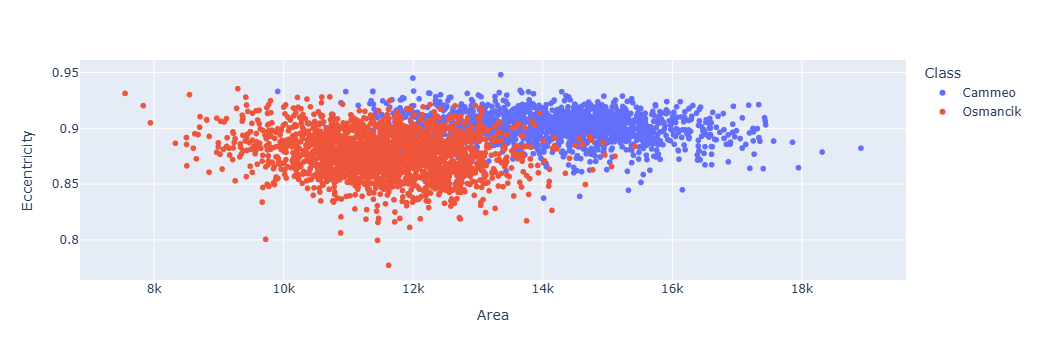

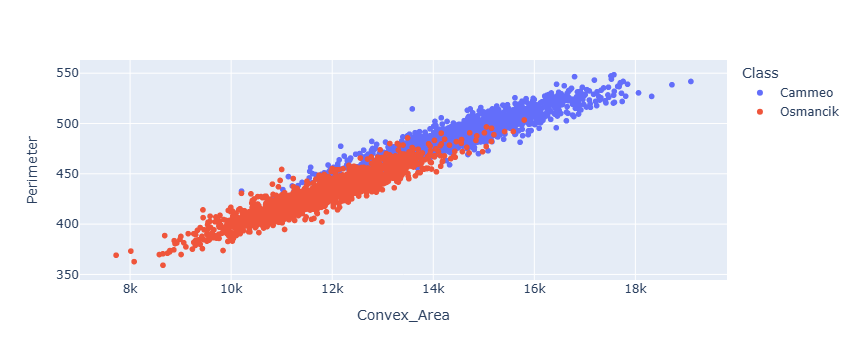

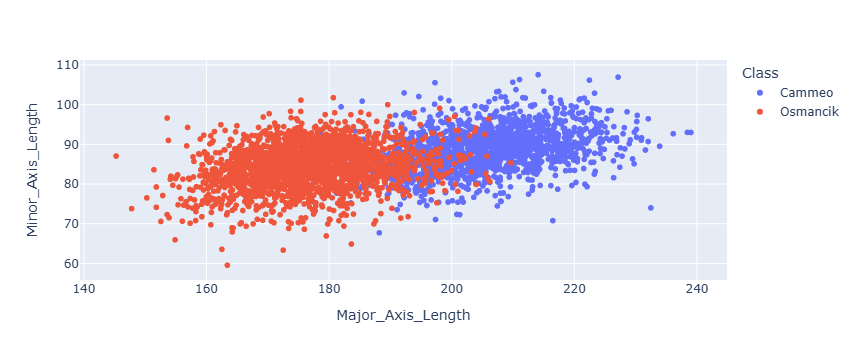

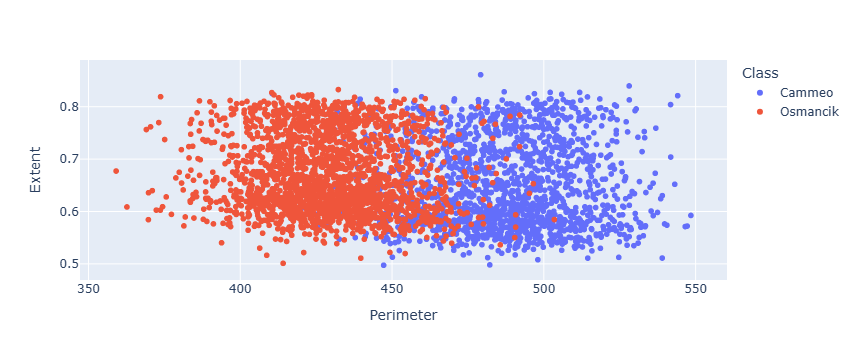

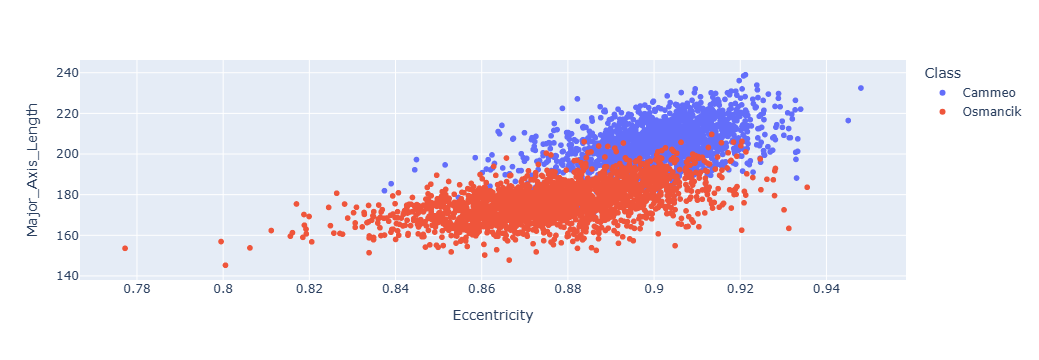

In [8]:
for x_axis, y_axis in[
    ('Area','Eccentricity'),
    ('Convex_Area', 'Perimeter' ),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
    ]:
    px.scatter(rice_dataset_raw, x=x_axis, y=y_axis, color='Class').show()


## If we were to pick three features, it seems that major axis length, area, and eccentricity might contain most of the information that differentiates the two classes. Other combinations may work as well.

Run the previous code cell to graph those three features if you haven't already.

It seems like a distinct class boundary appears in the plane of these three features. We'll train a model on just these features, then another model on the complete set of features, and compare their performance.

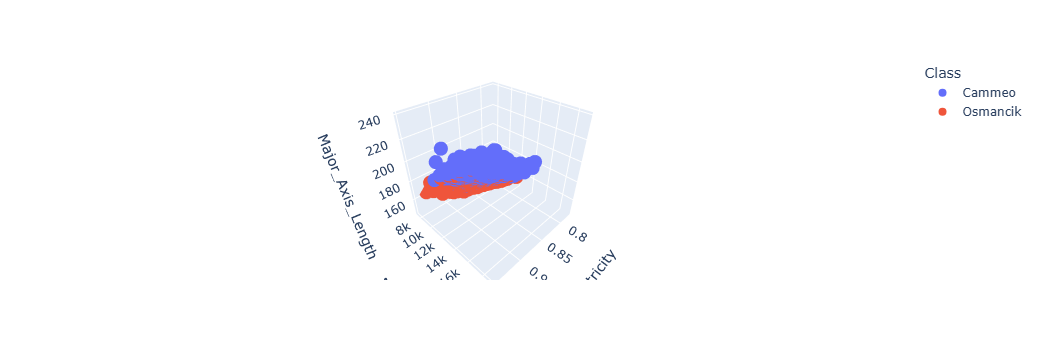

In [9]:
#pxscatter 3d 
px.scatter_3d(
    rice_dataset_raw, 
    x='Eccentricity', 
    y ='Area',
    z='Major_Axis_Length',
    color='Class',
).show()

In [10]:
rice_dataset_raw.shape

(3810, 8)

In [11]:
#Z-score  
feature_mean = rice_dataset_raw.mean(numeric_only =True)
feature_std = rice_dataset_raw.std(numeric_only=True) 
#to select all columns  

num_feature = rice_dataset_raw.select_dtypes('number').columns

#normalizezation formula  
normalization_dataset= ( 
    rice_dataset_raw[num_feature] - feature_mean ) /feature_std
normalization_dataset['Class'] = rice_dataset_raw['Class'] 


normalization_dataset.head()



,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.5,2.0,2.3,-0.2,2.0,1.5,-1.2,Cammeo
1,1.1,1.1,1.0,0.9,0.4,1.2,-0.6,Cammeo
2,1.1,1.3,1.5,0.3,1.2,1.1,0.4,Cammeo
3,0.3,0.1,0.3,0.2,0.2,0.2,-0.3,Cammeo
4,1.2,1.5,1.3,0.5,1.0,1.3,-0.2,Cammeo


In [12]:
keras.utils.set_random_seed(42)
# This means that if you run
#the same code multiple times, you will get the same results, 
#which is crucial for debugging and comparing models effectively.

In [13]:
## Create a column setting the Cammeo label to '1' and the Osmancik label to '0'
# then show 10 randomly selected rows.

normalization_dataset['Class_Bool'] = ( 
    normalization_dataset['Class'] == 'cammeo' 
).astype(int)
normalization_dataset.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,-0.1,0.1,-0.1,0.2,-0.1,-0.0,-1.0,Cammeo,0
3185,-0.1,-0.5,-0.5,0.4,-0.8,-0.2,-0.3,Osmancik,0
3698,0.1,-0.1,-0.4,0.9,-1.1,0.1,-0.2,Osmancik,0
897,0.2,0.5,0.8,-0.5,1.2,0.2,1.5,Cammeo,0
3245,-1.3,-1.3,-0.9,-1.6,0.5,-1.4,-1.1,Osmancik,0
478,0.2,0.2,0.4,-0.0,0.5,0.2,1.7,Cammeo,0
1731,-0.4,-0.8,-0.8,0.3,-1.0,-0.5,-0.4,Osmancik,0
1025,0.6,0.7,0.6,0.3,0.5,0.6,-0.5,Cammeo,0
429,1.2,1.2,1.4,0.6,1.0,1.2,1.8,Cammeo,0
1330,-0.4,-0.0,0.4,-1.3,1.4,-0.5,-0.1,Cammeo,0


In [14]:
# 80%, 10%, and 10% of the dataset respectively. 

num = len(normalization_dataset) 
index_80th =round(num*0.8) 
index_90th = index_80th + round(num*0.1)

#how to do shuffle  
shuffle_dataset = normalization_dataset.sample(frac=1, random_state=100)
train_data = shuffle_dataset.iloc[0:index_80th] 
validation_data = shuffle_dataset.iloc[index_80th:index_90th]
test_data = shuffle_dataset.iloc[index_90th:]

#show the first five row  
test_data.head() 


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
2405,-0.4,-0.7,-0.8,0.3,-1.1,-0.4,0.3,Osmancik,0
3062,-0.2,-0.0,0.2,-0.7,0.8,-0.2,1.6,Osmancik,0
1155,1.4,1.2,1.1,1.2,0.3,1.3,0.7,Cammeo,0
660,1.2,1.0,0.8,1.3,-0.0,1.2,-0.6,Cammeo,0
2451,-1.2,-1.2,-1.4,-0.3,-1.5,-1.1,0.1,Osmancik,0


In [15]:
label_columns = ['Class', 'Class_Bool']

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class_Bool'].to_numpy()
validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class_Bool'].to_numpy()
test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class_Bool'].to_numpy()

In [17]:
#title define  

def create_model( 
    settings: ml_edu.experiment.ExperimentSettings, 
    metrices: list[keras.metrics.Metric], 
) -> keras.Model: 

#this show how input look like shape and all 
    model_inputs = [ 
    keras.Input(name=feature,shape=(1,)) 
    for feature in settings.input_features 
    ] 

#every node containing the single input and single output 
#concatinating every single output together  
#making single layer of neuron  

    con_inputs = keras.layers.Concatenate()(model_inputs) 
    model_output = keras.layers.Dense(
    units=1,name='dense_layer',activation=keras.activations.sigmoid) 
    (con_inputs)

#now assign input and output to model
    model = keras.Model(inputs=model_inputs,outputs=model_output) 

# Call the compile method to transform the layers into a model that
# Keras can execute.  Notice that we're using a different loss
# function for classification than for regression.

    model.compile(
    optimizer=keras.optimizers.RMSprop(
        settings.learning_rate
    ),
    loss=keras.losses.BinaryCrossentropy(), 
    metrics=metrics,
    )

    return model 

def train_model( 
    experiment_name:str, 
    model:keras.Model,
    dataset:pd.DataFrame, 
    labels:np.ndarray, 
    settings:ml_edu.experiment.ExperimentSettings,
)-> ml_edu.experiment.Experiment: 
    
# The x parameter of keras.Model.fit can be a list of arrays, where
# each array contains the data for one feature.
    feature = {
    feature_name: np.array(dataset[feature_name]) 
    for feature_name in settings.input_features
    }

    history = model.fit(
        x=feature,
        y=labels,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs,
    )


    return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )










In [23]:
settings = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.35,
    input_features=input_features,
)

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy', threshold=settings.classification_threshold
    ),
    keras.metrics.Precision(
        name='precision', thresholds=settings.classification_threshold
    ),
    keras.metrics.Recall(
        name='recall', thresholds=settings.classification_threshold
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),
]

# Establish the model's topography.
model = create_model(settings, metrics)

# Train the model on the training set.
experiment = train_model(
    'baseline', model, train_features, train_labels, settings
)

NameError: name 'input_features' is not defined

In [ ]:
# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(experiment, ['accuracy', 'precision', 'recall'])
ml_edu.results.plot_experiment_metrics(experiment, ['auc'])

In [ ]:
def compare_train_validation(experiment: ml_edu.experiment.Experiment, validation_metrics: dict[str, float]):
  print('Comparing metrics between train and validation:')
  for metric, validation_value in validation_metrics.items():
    print('------')
    print(f'Train {metric}: {experiment.get_final_metric_value(metric):.4f}')
    print(f'Validation {metric}:  {validation_value:.4f}')


# Evaluate validation metrics
validation_metrics = experiment.evaluate(validation_features, validation_labels)
compare_train_validation(experiment, validation_metrics)